In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
from glob import glob

In [2]:
img_path = glob("D:\\python-venv\\U_NET\\data\\stage1_train//*//images//*.png")
mask_path1 = glob("D:\\python-venv\\U_NET\\data\\stage1_train//*//masks//*.png")

For monitoring the size of pictures to see that are they all from same size?

In [3]:
w = []
h = []
for path in img_path:
    img = cv2.imread(path)
    w.append(img.shape[0])
    h.append(img.shape[1]) 

In [4]:
min(w)

256

In [5]:
max(w)

1040

In [6]:
min(h)

256

In [7]:
max(h)

1388

In [8]:
w = []
h = []
for path in mask_path1:
    mask = cv2.imread(path)
    w.append(mask.shape[0])
    h.append(mask.shape[1]) 

In [9]:
min(w)

256

Then all of images are not in same size.

Lets set all to minimum.

In [10]:
input_w , input_h , output_w , output_h= 256 , 256 , 256 , 256
input_ch = 3
output_ch=1

Getting ready the imasges. Making a zero list for saving the images.

In [11]:
images = np.zeros((len(img_path) , input_h , input_w , input_ch) , dtype=np.uint8)
masks = np.zeros((len(img_path) , input_h , input_w) , dtype=np.uint8)

In [12]:
all_path_url = "D:\python-venv\\U_NET\\data\stage1_train\*"
mask_path = glob("D:\\python-venv\\U_NET\\data\\stage1_train//*//masks/")

In [13]:
all_path = glob(all_path_url)

In [14]:
for id_ , path in enumerate(all_path):
    path_image = glob(path + '/images/*.png')[0]
    images[id_] = cv2.resize(cv2.imread(path_image) , (256 , 256))

    msk_path = glob(path + "/masks/*.png")
    for path_ in msk_path:
        # (interpolation=cv2.INTER_NEAREST) Because of that we did the reshape (256,256) on mask images those are bigger than (256,256) for reshaping have to interpolate and if we dont set (interpolation=cv2.INTER_NEAREST) then the values were going worth.
        mask_ = cv2.resize(cv2.imread(path_,cv2.IMREAD_GRAYSCALE) , (256,256) , interpolation=cv2.INTER_NEAREST)
        masks[id_] =masks[id_] + mask_

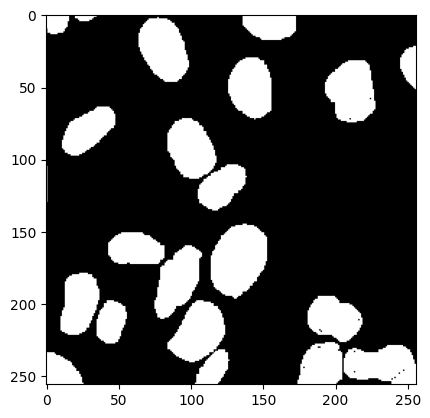

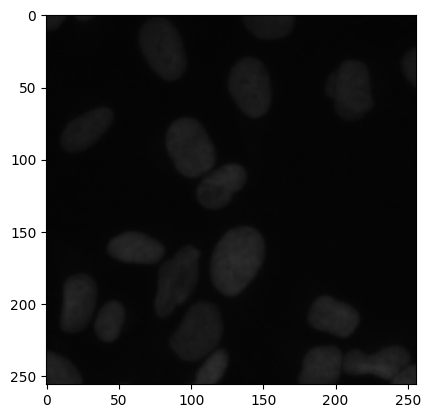

In [15]:
plt.imshow(masks[7]  , cmap='gray')
plt.show()
plt.imshow(images[7])
plt.show()

In [16]:
images = images / 255
masks = masks / 255

Now aour data is ready for get it to model.

In [17]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Conv2D, MaxPool2D,Conv2DTranspose ,Input, concatenate

In [18]:
input = Input(shape=(input_w,input_h,input_ch))

conv1_encoder = Conv2D(32,(3,3),activation='relu',padding='same',name='input_gray')(input)
conv1_encoder = Conv2D(32,(3,3),activation='relu',padding='same')(conv1_encoder)
pool1_encoder = MaxPool2D((2,2))(conv1_encoder)

conv2_encoder = Conv2D(64,(3,3),activation='relu',padding='same')(pool1_encoder)
conv2_encoder = Conv2D(64,(3,3),activation='relu',padding='same')(conv2_encoder)
pool2_encoder = MaxPool2D((2,2))(conv2_encoder)

conv3_encoder = Conv2D(128,(3,3),activation='relu',padding='same')(pool2_encoder)
conv3_encoder = Conv2D(128,(3,3),activation='relu',padding='same')(conv3_encoder)
pool3_encoder = MaxPool2D((2,2))(conv3_encoder)

conv4_encoder = Conv2D(256,(3,3),activation='relu',padding='same')(pool3_encoder)
conv4_encoder = Conv2D(256,(3,3),activation='relu',padding='same')(conv4_encoder)


up1_decoder = Conv2DTranspose(128,(2,2),strides=(2,2),padding='same')(conv4_encoder)
concat1 = concatenate([conv3_encoder,up1_decoder])
conv1_decoder = Conv2D(128,(3,3),activation='relu',padding='same')(concat1)
conv1_decoder = Conv2D(128,(3,3),activation='relu',padding='same')(conv1_decoder)

up2_decoder = Conv2DTranspose(64,(2,2),strides=(2,2),padding='same')(conv1_decoder)
concat2 = concatenate([conv2_encoder,up2_decoder])
conv2_decoder = Conv2D(64,(3,3),activation='relu',padding='same')(concat2)
conv2_decoder = Conv2D(64,(3,3),activation='relu',padding='same')(conv2_decoder)

up3_decoder = Conv2DTranspose(32,(2,2),strides=(2,2),padding='same')(conv2_decoder)
concat3 = concatenate([conv1_encoder,up3_decoder])
conv3_decoder = Conv2D(32,(3,3),activation='relu',padding='same')(concat3)
conv3_decoder = Conv2D(32,(3,3),activation='relu',padding='same')(conv3_decoder)

output = Conv2D(1,(1,1),activation='sigmoid',name='output_color')(conv3_decoder)

model = Model(inputs=[input],outputs=[output])

In [19]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_gray (Conv2D) │ (None, 256, 256,  │        896 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 256, 256,  │      9,248 │ input_gray[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 128, 128,  │          0 │ conv2d[0][0]      │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 128, 128,  │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 128, 128,  │     36,928 │ conv2d_1[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 64, 64,    │          0 │ conv2d_2[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 64, 64,    │     73,856 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 64, 64,    │    147,584 │ conv2d_3[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 32, 32,    │          0 │ conv2d_4[0][0]    │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 32, 32,    │    295,168 │ max_pooling2d_2[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 32, 32,    │    590,080 │ conv2d_5[0][0]    │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose    │ (None, 64, 64,    │    131,200 │ conv2d_6[0][0]    │
│ (Conv2DTranspose)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 64, 64,    │          0 │ conv2d_4[0][0],   │
│ (Concatenate)       │ 256)              │            │ conv2d_transpose… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 64, 64,    │    295,040 │ concatenate[0][0] │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 64, 64,    │    147,584 │ conv2d_7[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_1  │ (None, 128, 128,  │     32,832 │ conv2d_8[0][0]  

 Total params: 1,925,601 (7.35 MB)

 Trainable params: 1,925,601 (7.35 MB)

 Non-trainable params: 0 (0.00 B)

In [20]:
opt = tf.keras.optimizers.Adam(0.001)
loss = tf.keras.losses.BinaryCrossentropy()
model.compile(optimizer=opt,loss=loss)

In [21]:
model.fit(images,masks,validation_split=0.1,batch_size=50,epochs=13,verbose=2)

Epoch 1/13
13/13 - 148s - 11s/step - loss: 0.6313 - val_loss: 0.5808
Epoch 2/13
13/13 - 139s - 11s/step - loss: 0.4690 - val_loss: 0.3677
Epoch 3/13
13/13 - 141s - 11s/step - loss: 0.3656 - val_loss: 0.2783
Epoch 4/13
13/13 - 140s - 11s/step - loss: 0.2931 - val_loss: 0.2385
Epoch 5/13
13/13 - 142s - 11s/step - loss: 0.2502 - val_loss: 0.1969
Epoch 6/13
13/13 - 141s - 11s/step - loss: 0.2688 - val_loss: 0.3497
Epoch 7/13
13/13 - 141s - 11s/step - loss: 0.3238 - val_loss: 0.2359
Epoch 8/13
13/13 - 144s - 11s/step - loss: 0.2542 - val_loss: 0.2121
Epoch 9/13
13/13 - 143s - 11s/step - loss: 0.2357 - val_loss: 0.1990
Epoch 10/13
13/13 - 147s - 11s/step - loss: 0.2193 - val_loss: 0.1886
Epoch 11/13
13/13 - 217s - 17s/step - loss: 0.1924 - val_loss: 0.1928
Epoch 12/13
13/13 - 163s - 13s/step - loss: 0.2298 - val_loss: 0.1725
Epoch 13/13
13/13 - 166s - 13s/step - loss: 0.1743 - val_loss: 0.1360


In [25]:
pred = model.predict(images[:5])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 203ms/step


In [26]:
pred = (pred >0.5).astype(int)

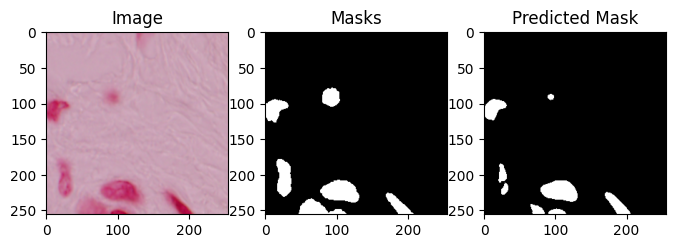

In [30]:
plt.figure(figsize=(8, 4))
index = 4
plt.subplot(1, 3, 1)
plt.imshow(images[index])
plt.title('Image')

plt.subplot(1, 3, 2)
plt.imshow(masks[index], cmap='gray')
plt.title('Masks')

plt.subplot(1, 3, 3)
plt.imshow(pred[index] , cmap='gray')
plt.title('Predicted Mask')

plt.show()